In [ ]:
import pandas as pd

df = pd.read_excel("SUPER MARKET DATA.xlsx")

df.head()

,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [ ]:
# Check the size of the dataset
print("Rows and Columns:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

Rows and Columns: (500, 13)

Column Names:
['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']

Data Types:
Invoice ID               object
Date             datetime64[ns]
Branch                   object
City                     object
Customer Type            object
Gender                   object
Product                  object
Category                 object
Quantity                  int64
Unit Price              float64
Payment                  object
Rating                  float64
Sales                   float64
dtype: object


In [ ]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
# Check numerical columns
print(df[["Quantity", "Unit Price", "Rating", "Sales"]].describe())

         Quantity  Unit Price      Rating        Sales
count  500.000000  500.000000  500.000000   500.000000
mean     5.536000   88.660700    3.994400   488.822160
std      2.875629   57.284029    0.574481   437.327833
min      1.000000   27.670000    3.000000    28.610000
25%      3.000000   43.955000    3.500000   189.212500
50%      5.500000   61.880000    4.000000   335.910000
75%      8.000000  128.567500    4.500000   609.885000
max     10.000000  236.710000    5.000000  2114.820000


In [ ]:
# Calculate Sales independently
calculated_sales = df["Quantity"] * df["Unit Price"]

# Compare calculated sales with the existing Sales column
difference = (calculated_sales - df["Sales"]).abs()

print("Maximum difference:", difference.max())

print("\nNumber of mismatched rows:", (difference > 0.01).sum())

Maximum difference: 4.547473508864641e-13

Number of mismatched rows: 0


In [ ]:
# Total sales by product
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print(product_sales)

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Chocolate       7250.65
Noodles         7191.24
Potato          6799.38
Bread           6516.10
Soap            6499.63
Bananas         6205.76
Chips           5833.45
Milk            5655.93
Tomato          4324.79
Biscuits        3908.87
Name: Sales, dtype: float64


In [ ]:
# Total sales by branch
branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)

print(branch_sales)

Branch
C    72469.45
B    64116.26
D    55468.29
A    52357.08
Name: Sales, dtype: float64


In [ ]:
# Total sales by category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

print(category_sales)

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64


In [ ]:
# Count transactions by payment method
payment_counts = df["Payment"].value_counts()

print(payment_counts)

Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64


In [ ]:
# Average sales by customer type
customer_sales = df.groupby("Customer Type")["Sales"].mean().sort_values(ascending=False)

print(customer_sales)

Customer Type
Normal    497.067549
Member    483.139527
Name: Sales, dtype: float64


In [ ]:
# Calculate average customer rating
average_rating = df["Rating"].mean()

print("Average Customer Rating:", round(average_rating, 2))

Average Customer Rating: 3.99


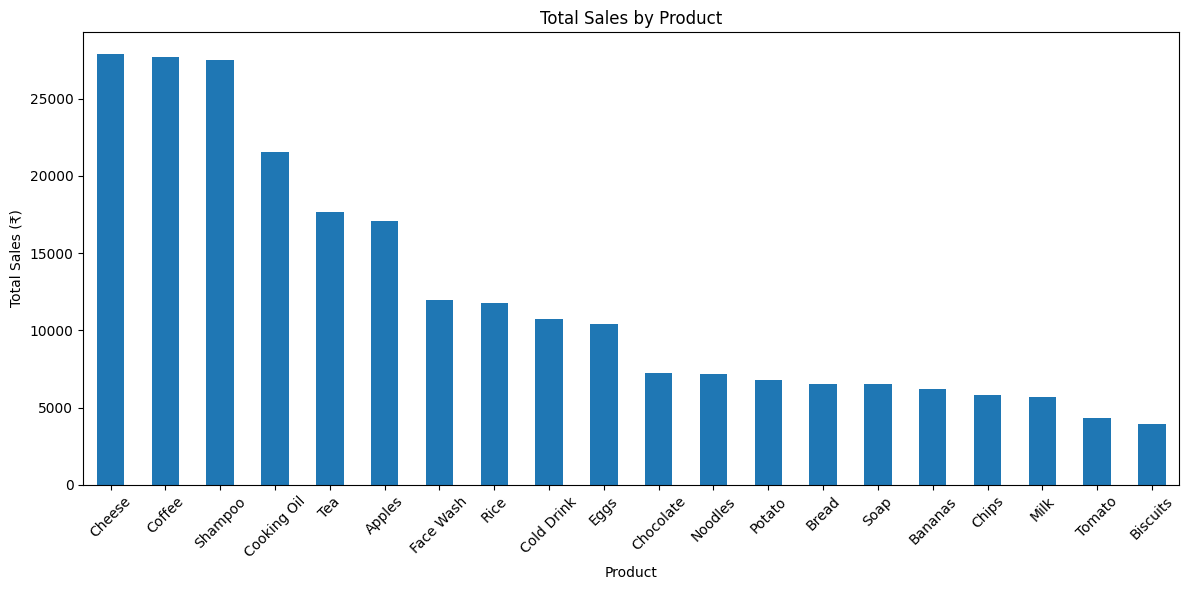

In [ ]:
import matplotlib.pyplot as plt

product_sales.plot(kind="bar", figsize=(12, 6))

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

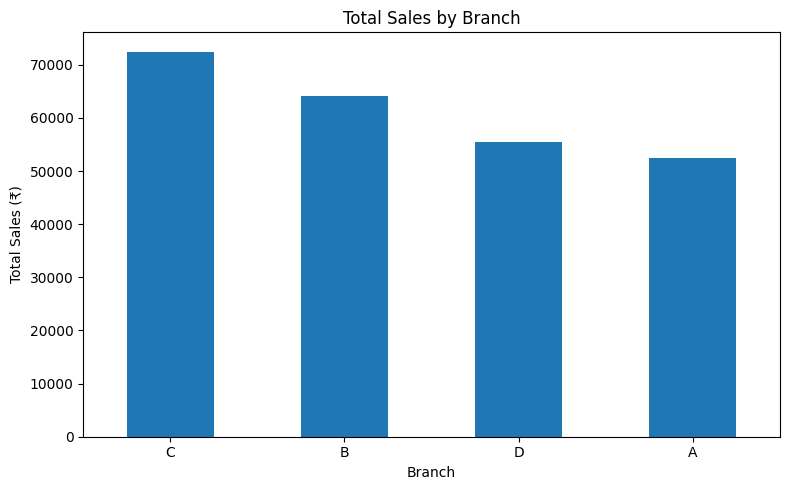

In [ ]:
# Sales by Branch
branch_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

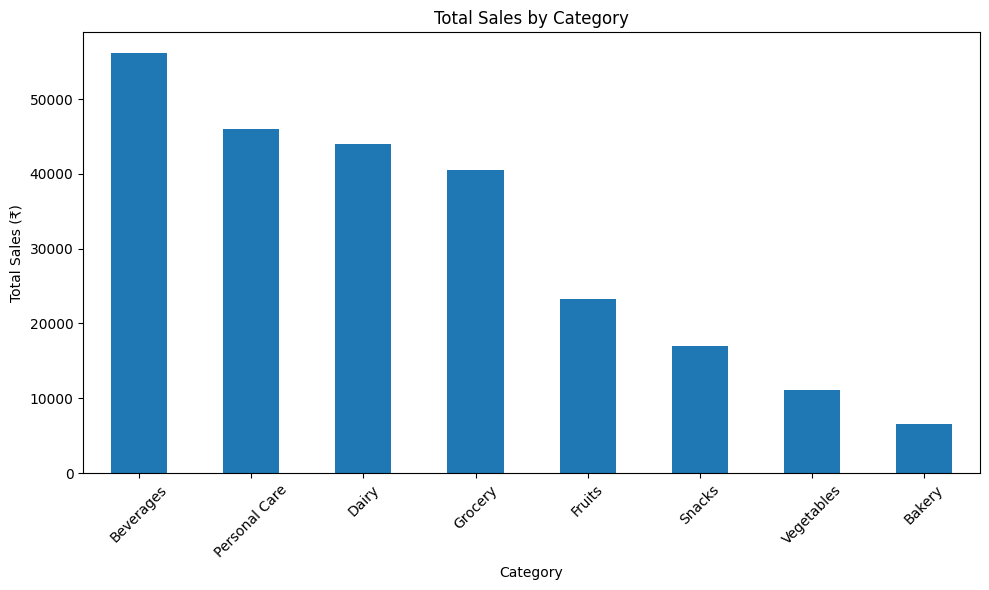

In [ ]:
# Sales by Category
category_sales.plot(kind="bar", figsize=(10, 6))

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

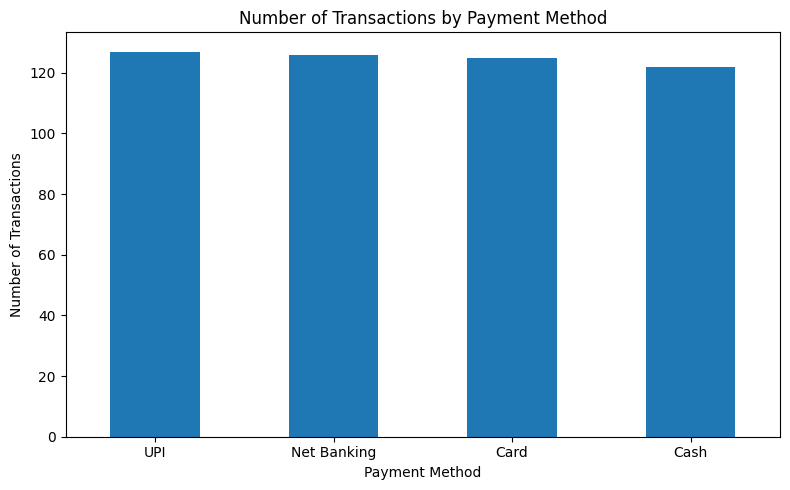

In [ ]:
# Transactions by Payment Method
payment_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Number of Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

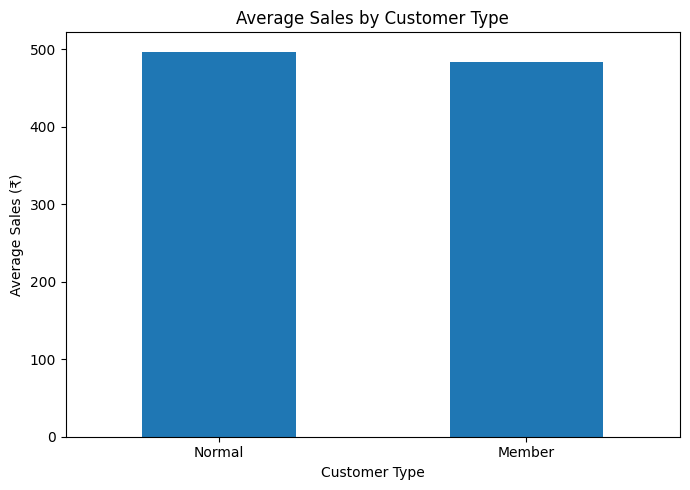

In [ ]:
# Average sales by customer type
customer_sales.plot(kind="bar", figsize=(7, 5))

plt.title("Average Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Average Sales (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

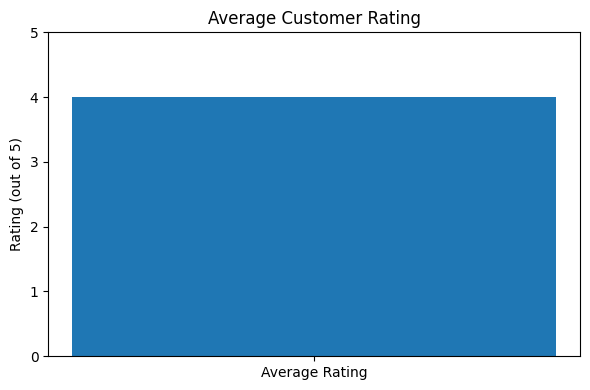

In [ ]:
# Average Customer Rating
plt.figure(figsize=(6, 4))

plt.bar(["Average Rating"], [average_rating])

plt.title("Average Customer Rating")
plt.ylabel("Rating (out of 5)")
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate total sales
total_sales = df["Sales"].sum()

print("Total Sales: ₹", round(total_sales, 2))

Total Sales: ₹ 244411.08


In [ ]:
# Total sales by city
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False)

print(city_sales)

City
Mumbai       72469.45
Delhi        64116.26
Bengaluru    55468.29
Jaipur       52357.08
Name: Sales, dtype: float64


In [ ]:
# Total quantity sold
total_quantity = df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 2768


In [ ]:
# Count unique transactions
total_transactions = df["Invoice ID"].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 500


In [ ]:
total_sales = df["Sales"].sum()

print("Total Sales: ₹", round(total_sales, 2))

Total Sales: ₹ 244411.08


In [ ]:
print("===== FINAL BUSINESS INSIGHTS =====")

print("1. Highest-selling product: Cheese - ₹27,906.30")
print("2. Highest-performing branch: Branch C - ₹72,469.45")
print("3. Highest-selling category: Beverages - ₹56,108.24")
print("4. Most-used payment method: UPI - 127 transactions")
print("5. Higher average transaction value: Normal customers - ₹497.07")
print("6. Average customer rating: 3.99 out of 5")
print("7. Total sales: ₹244,411.08")
print("8. Total quantity sold: 2,768 units")
print("9. Total transactions: 500")

===== FINAL BUSINESS INSIGHTS =====
1. Highest-selling product: Cheese - ₹27,906.30
2. Highest-performing branch: Branch C - ₹72,469.45
3. Highest-selling category: Beverages - ₹56,108.24
4. Most-used payment method: UPI - 127 transactions
5. Higher average transaction value: Normal customers - ₹497.07
6. Average customer rating: 3.99 out of 5
7. Total sales: ₹244,411.08
8. Total quantity sold: 2,768 units
9. Total transactions: 500


In [ ]:
print("===== BUSINESS DECISIONS / RECOMMENDATIONS =====")

print("1. Keep sufficient stock of high-selling products such as Cheese.")
print("2. Maintain and study the successful performance of Branch C in Mumbai.")
print("3. Ensure good availability of high-selling categories such as Beverages.")
print("4. Continue supporting UPI payments because it is the most-used payment method.")
print("5. Use customer spending patterns to design attractive membership offers.")
print("6. Improve customer service and shopping experience to increase the average rating above 3.99.")

===== BUSINESS DECISIONS / RECOMMENDATIONS =====
1. Keep sufficient stock of high-selling products such as Cheese.
2. Maintain and study the successful performance of Branch C in Mumbai.
3. Ensure good availability of high-selling categories such as Beverages.
4. Continue supporting UPI payments because it is the most-used payment method.
5. Use customer spending patterns to design attractive membership offers.
6. Improve customer service and shopping experience to increase the average rating above 3.99.


In [ ]:
print("===== CONCLUSION =====")

print("The supermarket sales analysis of 500 transactions provided useful insights into")
print("products, branches, categories, customers, payment methods, and customer ratings.")
print("The dataset generated total sales of ₹244,411.08 from 2,768 units sold.")
print("Cheese was the highest-selling product, Branch C in Mumbai had the highest branch")
print("sales, and Beverages was the highest-selling category. UPI was the most-used")
print("payment method, while the average customer rating was 3.99 out of 5.")
print("These findings can help the supermarket improve inventory management, understand")
print("branch performance, support preferred payment methods, improve customer service,")
print("and develop better customer offers.")

===== CONCLUSION =====
The supermarket sales analysis of 500 transactions provided useful insights into
products, branches, categories, customers, payment methods, and customer ratings.
The dataset generated total sales of ₹244,411.08 from 2,768 units sold.
Cheese was the highest-selling product, Branch C in Mumbai had the highest branch
sales, and Beverages was the highest-selling category. UPI was the most-used
payment method, while the average customer rating was 3.99 out of 5.
These findings can help the supermarket improve inventory management, understand
branch performance, support preferred payment methods, improve customer service,
and develop better customer offers.


In [ ]:
final_results = {
    "Total Sales": round(total_sales, 2),
    "Total Quantity Sold": total_quantity,
    "Total Transactions": total_transactions,
    "Highest-Selling Product": product_sales.idxmax(),
    "Highest Product Sales": round(product_sales.max(), 2),
    "Highest-Performing Branch": branch_sales.idxmax(),
    "Highest Branch Sales": round(branch_sales.max(), 2),
    "Highest-Selling Category": category_sales.idxmax(),
    "Highest Category Sales": round(category_sales.max(), 2),
    "Most-Used Payment Method": payment_counts.idxmax(),
    "Most-Used Payment Transactions": payment_counts.max(),
    "Average Customer Rating": round(average_rating, 2)
}

print("===== FINAL RESULTS SUMMARY =====")

for key, value in final_results.items():
    print(f"{key}: {value}")

===== FINAL RESULTS SUMMARY =====
Total Sales: 244411.08
Total Quantity Sold: 2768
Total Transactions: 500
Highest-Selling Product: Cheese
Highest Product Sales: 27906.3
Highest-Performing Branch: C
Highest Branch Sales: 72469.45
Highest-Selling Category: Beverages
Highest Category Sales: 56108.24
Most-Used Payment Method: UPI
Most-Used Payment Transactions: 127
Average Customer Rating: 3.99
